In [2]:
import pandas as pd

In [3]:
physical = pd.read_csv("../data/Tamil_physical_parameters.csv")
chemical = pd.read_csv("../data/Tamil_chemical_parameters.csv")
biological = pd.read_csv("../data/Tamil_biological_parameters.csv")

In [4]:
common_columns = list(set(physical.columns.intersection(chemical.columns).intersection(biological.columns)))

In [5]:
merge_keys = ["Station","Data Acquisition Time"]

physical.duplicated(subset=merge_keys).sum()
chemical.duplicated(subset=merge_keys).sum()
biological.duplicated(subset=merge_keys).sum()

np.int64(0)

In [6]:
physical[merge_keys].isnull().sum()
chemical[merge_keys].isnull().sum()
biological[merge_keys].isnull().sum()

Station                  0
Data Acquisition Time    0
dtype: int64

In [7]:
physical_keys = set(zip(physical["Station"], physical["Data Acquisition Time"]))
chemical_keys = set(zip(chemical["Station"], chemical["Data Acquisition Time"]))
biological_keys = set(zip(biological["Station"], biological["Data Acquisition Time"]))

In [8]:
physical_keys - chemical_keys
chemical_keys - physical_keys

physical_keys - biological_keys
biological_keys - physical_keys

chemical_keys - biological_keys
biological_keys - chemical_keys

set()

In [9]:
repeated_columns = list(set(common_columns)-set(merge_keys))

In [10]:
chemical_2 = chemical.drop(columns=repeated_columns)
biological_2 = biological.drop(columns=repeated_columns)

In [11]:
merged_1 = pd.merge(physical,chemical_2,how='inner',on = merge_keys)
merged_2 = pd.merge(merged_1,biological_2,how='inner',on = merge_keys)

In [12]:
merged_2.isnull().sum()

SlNo                                   0
Station                                0
Agency                                 0
State LGD Code                         0
State                                  0
                                    ... 
Copper (mg/L)                       2572
Biochemical Oxygen Demand (mg/L)      15
Chemical Oxygen Demand (mg/L)       2815
Fecal Coliform (MPN/100mL)          2804
Total Coliform (MPN/100mL)          2803
Length: 62, dtype: int64

In [13]:
merged_2.groupby("River").agg(lambda x: x.isnull().sum())

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,...,Nickel (mg/L),Lead (mg/L),Zinc (mg/L),Sodium Adsorption Ratio (%),Nitrate (mg/L),Copper (mg/L),Biochemical Oxygen Demand (mg/L),Chemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL),Total Coliform (MPN/100mL)
River,,,,,,,,,,,,,,,,,,,,,
Bharathapuzha,0,0,0,0,0,0,0,0,0,0,...,160,160,155,0,172,158,0,172,172,172
Cauvery,0,0,0,0,0,0,0,0,0,0,...,1633,1630,1609,42,1755,1613,6,1755,1755,1754
Duplicate-Palar,0,0,0,0,0,0,0,0,0,0,...,78,78,78,11,90,78,0,90,90,90
Duplicate-Ponnaiyar,0,0,0,0,0,0,0,0,0,0,...,308,305,304,29,336,305,9,336,336,336
Duplicate-Vaigai,0,0,0,0,0,0,0,0,0,0,...,233,232,227,0,251,229,0,251,240,240
Duplicate-Vellar,0,0,0,0,0,0,0,0,0,0,...,21,21,21,3,24,21,0,24,24,24
Tambraparani,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,1,1,0,1,1,1
Thambraparani,0,0,0,0,0,0,0,0,0,0,...,171,172,166,0,185,167,0,185,185,185
Thambraparni,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,1


In [14]:
merged_2["Dissolved oxygen (mg/L)"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2815 entries, 0 to 2814
Series name: Dissolved oxygen (mg/L)
Non-Null Count  Dtype  
--------------  -----  
2449 non-null   float64
dtypes: float64(1)
memory usage: 22.1 KB


**From the above, we can conclude that we should remove columns that contain no data at all. We are using COD as a reference because we already know that the COD data is missing. Therefore, the columns Nitrate, COD, Fecal Coliform, and Total Coliform will be removed because they contain no data.

We will also remove columns such as Nickel, Lead, Zinc, Copper, and others because they contain little to no data. To handle this systematically, we will remove all columns with more than 15% missing values.**

**To remove columns of 15% more null values we will use .dropna(axis=0/1, how ="any"/"all", thresh = ..), 0/1 (rows/columns), how is conditional, not necessary, if "any" then if any value is null then remove the column, similarly for "all", and for thresh it can be used instead of how if you want toremove column on certain present quantity.**

In [15]:
threshold = 0.85*len(merged_2)

In [16]:
merged = merged_2.dropna(axis=1,thresh=threshold).copy()

In [17]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2815 entries, 0 to 2814
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   SlNo                              2815 non-null   int64  
 1   Station                           2815 non-null   object 
 2   Agency                            2815 non-null   object 
 3   State LGD Code                    2815 non-null   int64  
 4   State                             2815 non-null   object 
 5   District LGD Code                 2815 non-null   int64  
 6   District                          2815 non-null   object 
 7   Tehsil                            2815 non-null   object 
 8   Block                             2815 non-null   object 
 9   Village                           2815 non-null   object 
 10  River                             2815 non-null   object 
 11  Basin                             2815 non-null   object 
 12  Tribut

**WQI = SUM(Wi*Qi)/SUM(Wi)**

**Three weighting approaches were reviewed: (i) Brown et al. (1972) mathematical weighting, (ii) expert-assigned weighting, and (iii) entropy/AHP-based weighting. The Brown et al. method was selected because it provides objective, reproducible weights based on standard permissible limits and avoids subjectivity associated with expert judgment.**

**A parameter is included in the Weighted Arithmetic Water Quality Index (Brown et al., 1972) only if it satisfies three conditions:
1. It is measured quantitatively.
2. It has an officially recognized standard permissible value (Si) from sources such as BIS or CPCB.
3. It is relevant to water quality assessment.**

**Colour is included because BIS IS 10500 specifies an acceptable limit of 5 TCU (Hazen units), allowing the calculation of both the unit weight (Wi) and quality rating (Qi). However, this is only applicable if colour is recorded as a numerical value (TCU/Hazen). If colour is recorded as categorical values (e.g., Colourless, Light Yellow), it should be excluded.
Bicarbonate is excluded because neither BIS IS 10500 nor CPCB specifies a permissible standard value for bicarbonate. Without a valid standard value (Si), the unit weight (Wi = K/Si) and quality rating (Qi) cannot be calculated, making it unsuitable for inclusion in the Brown et al. WQI.**

In [18]:
print(merged_2["Colour"].unique())

['Clear' 'Light Brown' 'Dark Green' 'Brown' nan 'Other' 'Light Green'
 'Dark Brown' 'Green']


In [19]:
S = {
    "Electric Conductivity (μS/cm)": 1500,
    "Calcium (mg/L)": 75,
    "Chloride (mg/L)": 250,
    "Dissolved oxygen (mg/L)": 5,
    "Magnesium (mg/L)": 30,
    "Sodium (mg/L)": 200,
    "Potential of Hydrogen (pH)": 8.5,
    "Sulphate (mg/L)": 200,
    "Total Alkalinity (mg/L as CaCO3)": 200,
    "Total Hardness (mgCaCO3/L)": 200,
    "Nitrate N (mgN/L)": 10,
    "Biochemical Oxygen Demand (mg/L)": 3
}

In [20]:
one_by_s = {parameter: 1/value for parameter, value in S.items()}

In [21]:
K = 1 / sum(one_by_s.values())

In [22]:
K

1.216080881300968

**W is weightage of all parameters in Water Quality Index(WQI)**

In [23]:
W = {parameter: K/value for parameter, value in S.items()}

In [24]:
W

{'Electric Conductivity (μS/cm)': 0.0008107205875339787,
 'Calcium (mg/L)': 0.016214411750679572,
 'Chloride (mg/L)': 0.004864323525203872,
 'Dissolved oxygen (mg/L)': 0.2432161762601936,
 'Magnesium (mg/L)': 0.04053602937669894,
 'Sodium (mg/L)': 0.00608040440650484,
 'Potential of Hydrogen (pH)': 0.14306833897658447,
 'Sulphate (mg/L)': 0.00608040440650484,
 'Total Alkalinity (mg/L as CaCO3)': 0.00608040440650484,
 'Total Hardness (mgCaCO3/L)': 0.00608040440650484,
 'Nitrate N (mgN/L)': 0.1216080881300968,
 'Biochemical Oxygen Demand (mg/L)': 0.40536029376698934}

**V0 is Ideal Value**

In [25]:
V0 = {
    "Electric Conductivity (μS/cm)": 0,
    "Calcium (mg/L)": 0,
    "Chloride (mg/L)": 0,
    "Dissolved oxygen (mg/L)": 14.6,
    "Magnesium (mg/L)": 0,
    "Sodium (mg/L)": 0,
    "Potential of Hydrogen (pH)": 7.0,
    "Sulphate (mg/L)": 0,
    "Total Alkalinity (mg/L as CaCO3)": 0,
    "Total Hardness (mgCaCO3/L)": 0,
    "Nitrate N (mgN/L)": 0,
    "Biochemical Oxygen Demand (mg/L)": 0
}

**Q is Quality Rating**

In [26]:
Q = pd.DataFrame(index=merged_2.index)

for parameter in S:
    Q[parameter] = (
        (merged_2[parameter] - V0[parameter])
        / (S[parameter] - V0[parameter])
    ) * 100

In [27]:
Q

,Electric Conductivity (μS/cm),Calcium (mg/L),Chloride (mg/L),Dissolved oxygen (mg/L),Magnesium (mg/L),Sodium (mg/L),Potential of Hydrogen (pH),Sulphate (mg/L),Total Alkalinity (mg/L as CaCO3),Total Hardness (mgCaCO3/L),Nitrate N (mgN/L),Biochemical Oxygen Demand (mg/L)
0,30.800000,57.600000,5.496,82.291667,61.673400,11.85,77.333333,7.623,100.795080,92.545875,20.00,66.666667
1,15.333333,29.920000,5.016,73.958333,42.133333,5.05,77.333333,3.715,50.815575,54.383335,9.67,33.333333
2,16.133333,29.920000,4.820,73.958333,29.166667,8.05,59.333333,1.150,51.901638,46.279167,10.20,26.666667
3,13.466667,29.920000,4.100,79.166667,25.933333,4.45,76.666667,1.385,41.303280,44.258335,7.21,30.000000
4,9.933333,21.373333,3.144,76.041667,19.333333,3.05,30.000000,1.165,34.442625,32.120835,3.45,26.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
2810,26.266667,35.626667,20.924,NaN,45.933333,15.85,50.666667,8.910,57.471310,62.108335,3.78,91.333333
2811,41.133333,51.653333,38.548,NaN,59.433333,28.35,62.000000,12.180,82.758195,85.570840,4.31,60.666667
2812,60.866667,49.333333,62.120,NaN,68.000000,60.00,6.666667,18.450,88.500000,88.500000,18.50,43.333333
2813,41.733333,24.000000,47.040,NaN,74.666667,40.00,93.333333,13.400,52.500000,68.500000,1.00,73.333333


In [28]:
WQI = Q.mul(pd.Series(W), axis=1).sum(axis=1) / sum(W.values())

merged["WQI"] = WQI

**okay so here Q is data frame and W is a dictionary, and .mul is used to multiply, $$axis=1 helps pd to multiply only if columns match$$ .sum(axis=1) tells that it need to sum all**

In [29]:
merged["WQI"].describe()

count    2815.000000
mean       60.047007
std        44.693107
min       -11.580871
25%        40.565248
50%        50.369217
75%        65.275491
max       596.710027
Name: WQI, dtype: float64

In [30]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2815 entries, 0 to 2814
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   SlNo                              2815 non-null   int64  
 1   Station                           2815 non-null   object 
 2   Agency                            2815 non-null   object 
 3   State LGD Code                    2815 non-null   int64  
 4   State                             2815 non-null   object 
 5   District LGD Code                 2815 non-null   int64  
 6   District                          2815 non-null   object 
 7   Tehsil                            2815 non-null   object 
 8   Block                             2815 non-null   object 
 9   Village                           2815 non-null   object 
 10  River                             2815 non-null   object 
 11  Basin                             2815 non-null   object 
 12  Tribut

In [31]:
merged.nlargest(10, "WQI")[["River", "Station", "WQI"]]

,River,Station,WQI
2034,Duplicate-Ponnaiyar,SINGASADANAPALLI,596.710027
2061,Duplicate-Ponnaiyar,SINGASADANAPALLI,566.180526
2041,Duplicate-Ponnaiyar,SINGASADANAPALLI,525.307067
2040,Duplicate-Ponnaiyar,SINGASADANAPALLI,433.193593
2064,Duplicate-Ponnaiyar,SINGASADANAPALLI,419.711997
2063,Duplicate-Ponnaiyar,SINGASADANAPALLI,417.731598
2047,Duplicate-Ponnaiyar,SINGASADANAPALLI,416.129081
2060,Duplicate-Ponnaiyar,SINGASADANAPALLI,409.375063
2055,Duplicate-Ponnaiyar,SINGASADANAPALLI,408.641909
2035,Duplicate-Ponnaiyar,SINGASADANAPALLI,404.340750


In [32]:
merged["Station"].nunique()

32

In [33]:
def classify_wqi(wqi):
    if wqi <= 25:
        return "Excellent"
    elif wqi <= 50:
        return "Good"
    elif wqi <= 75:
        return "Poor"
    elif wqi <= 100:
        return "Very Poor"
    else:
        return "Unsuitable"

merged["WQI Class"] = merged["WQI"].apply(classify_wqi)

In [34]:
merged["River"].unique()

array(['Bharathapuzha', 'Duplicate-Vaigai', 'Tambraparani',
       'Duplicate-Palar', 'Cauvery', 'Duplicate-Ponnaiyar',
       'Duplicate-Vellar', 'Thambraparni', 'Thambraparani'], dtype=object)

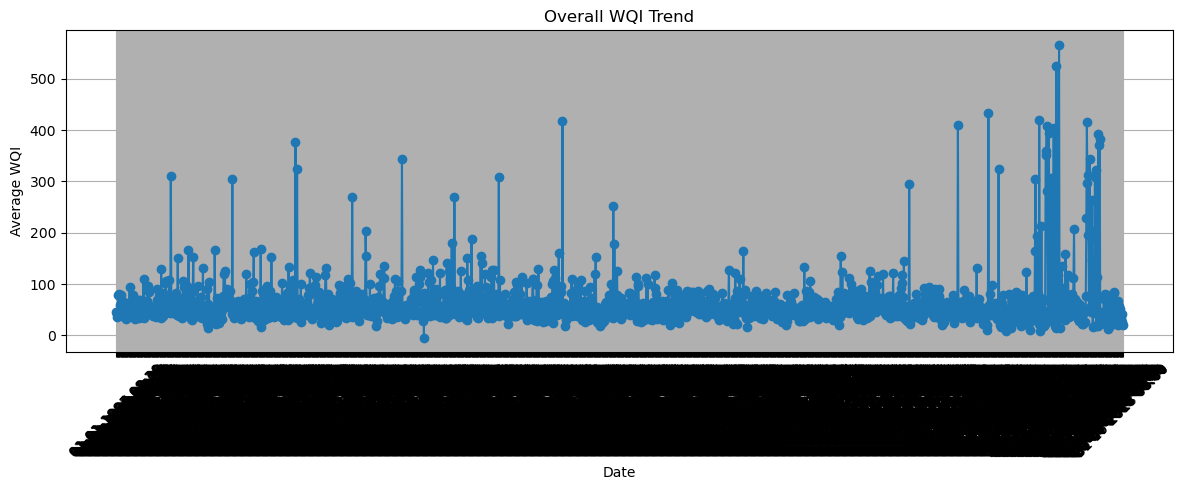

In [35]:
import matplotlib.pyplot as plt

overall_trend = (
    merged.groupby("Data Acquisition Time")["WQI"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(12,5))
plt.plot(overall_trend.index, overall_trend.values, marker='o')
plt.title("Overall WQI Trend")
plt.xlabel("Date")
plt.ylabel("Average WQI")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

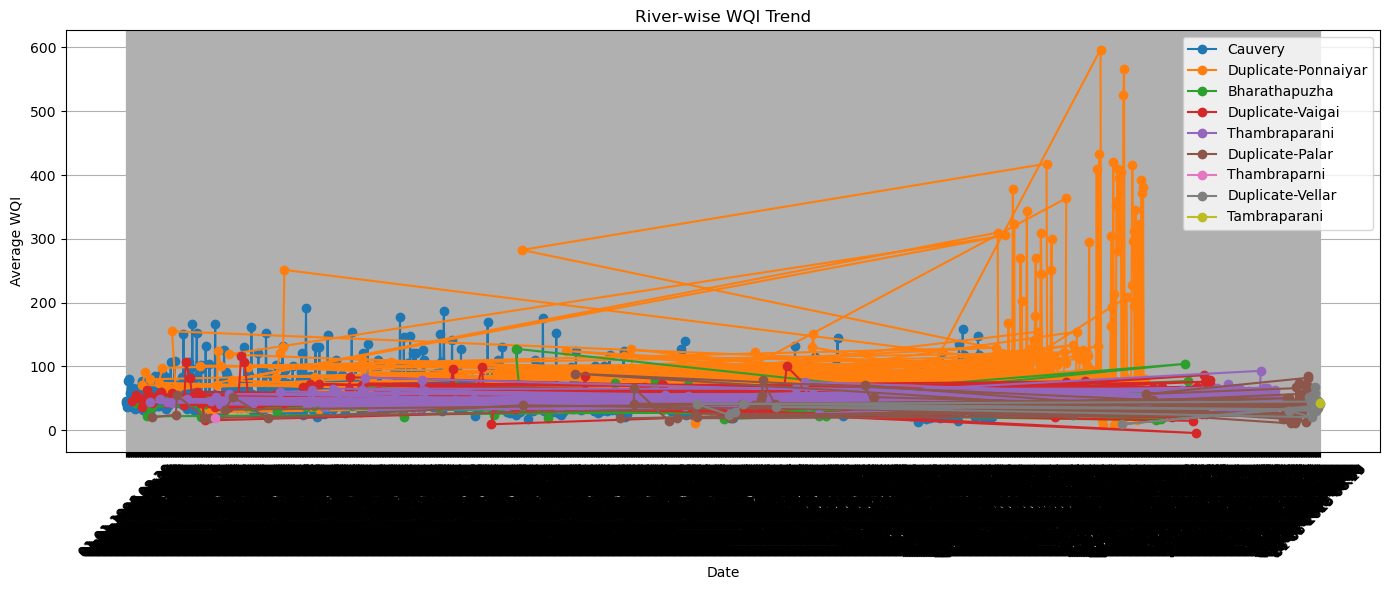

In [36]:
river_trend = (
    merged.groupby(["Data Acquisition Time", "River"])["WQI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

for river in river_trend["River"].unique():
    temp = river_trend[river_trend["River"] == river]
    plt.plot(
        temp["Data Acquisition Time"],
        temp["WQI"],
        marker='o',
        label=river
    )

plt.title("River-wise WQI Trend")
plt.xlabel("Date")
plt.ylabel("Average WQI")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

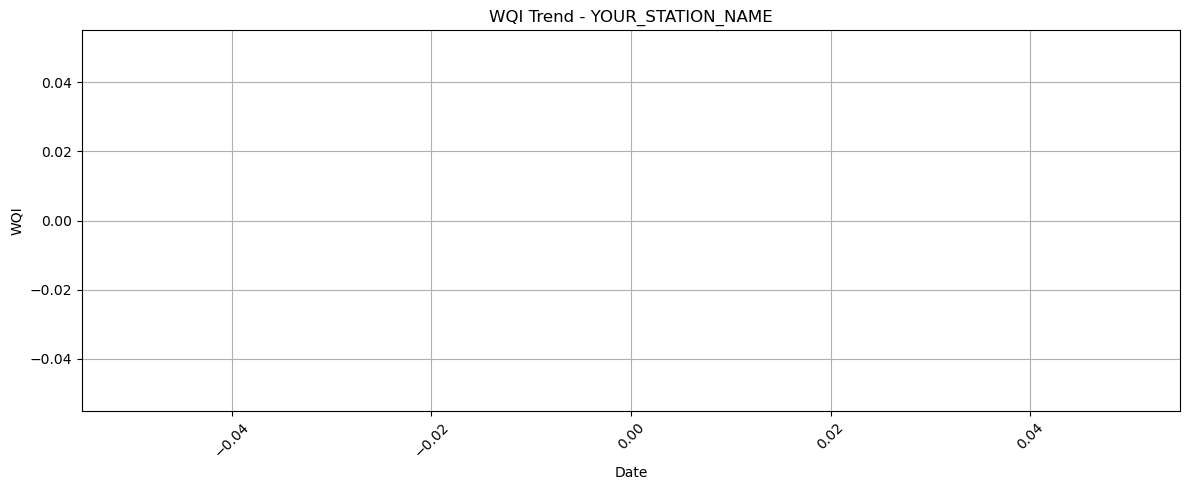

In [37]:
station = "YOUR_STATION_NAME"

temp = (
    merged[merged["Station"] == station]
    .sort_values("Data Acquisition Time")
)

plt.figure(figsize=(12,5))
plt.plot(
    temp["Data Acquisition Time"],
    temp["WQI"],
    marker='o'
)

plt.title(f"WQI Trend - {station}")
plt.xlabel("Date")
plt.ylabel("WQI")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd

df = pd.read_csv("River_WQI.csv", on_bad_lines='warn')
print(df.shape)

(2815, 39)
